In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
hdi_with_sc_path = '/mnt/warehouse/shifting_cultivation/111_result/output_file/world_hdi_latest_with_agri_percentage_fully.gpkg'

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [3]:
hdi_with_sc = gpd.read_file(hdi_with_sc_path)

In [4]:
hdi_with_sc = hdi_with_sc.to_crs(epsg=8857)  # World Cylindrical Equal Area

hdi_with_sc["subregion_area_km2"] = hdi_with_sc.geometry.area / 1e6

# Optional sanity check
print(hdi_with_sc["subregion_area_km2"].describe())

count    7.930000e+02
mean     4.885995e+04
std      1.035786e+05
min      7.177998e+00
25%      6.218667e+03
50%      2.069132e+04
75%      5.116110e+04
max      1.558172e+06
Name: subregion_area_km2, dtype: float64


In [5]:
hdi_with_sc.columns

Index(['iso_code', 'country', 'continent', 'gdlcode', 'region',
       'GDL-Subnational-HDI-data_field_1', 'GDL-Subnational-HDI-data_field_2',
       'GDL-Subnational-HDI-data_field_3', 'GDL-Subnational-HDI-data_field_4',
       'GDL-Subnational-HDI-data_field_6', 'GDL-Subnational-HDI-data_field_7',
       'GDL-Subnational-HDI-data_field_8', 'GDL-Subnational-HDI-data_field_9',
       'GDL-Subnational-HDI-data_field_10',
       'GDL-Subnational-HDI-data_field_11',
       'GDL-Subnational-HDI-data_field_12',
       'GDL-Subnational-HDI-data_field_13',
       'GDL-Subnational-HDI-data_field_14',
       'GDL-Subnational-HDI-data_field_15',
       'GDL-Subnational-HDI-data_field_16',
       'GDL-Subnational-HDI-data_field_17',
       'GDL-Subnational-HDI-data_field_18',
       'GDL-Subnational-HDI-data_field_19',
       'GDL-Subnational-HDI-data_field_20',
       'GDL-Subnational-HDI-data_field_21',
       'GDL-Subnational-HDI-data_field_22',
       'GDL-Subnational-HDI-data_field_23',
    

In [6]:
# # Clean
# hdi_with_sc = hdi_with_sc[
#     (hdi_with_sc["sc_landshare_pct"] >= 0) &
#     (hdi_with_sc["hdi_final_country_stats_continent_HDI_2020"].notna())
# ].copy()

In [7]:
col = "hdi_final_country_stats_continent_HDI_2020"

hdi_with_sc[col] = pd.to_numeric(
    hdi_with_sc[col],
    errors="coerce"   # convert bad strings to NaN
)

In [9]:
import pandas as pd

hdi_bins = [0, 0.55, 0.7, 0.8, 1.0]
hdi_labels = ["Low", "Medium", "High", "Very high"]

hdi_with_sc["HDI_class"] = pd.cut(
    hdi_with_sc["hdi_final_country_stats_continent_HDI_2020"],
    bins=hdi_bins,
    labels=hdi_labels,
    include_lowest=True
)

In [10]:
plot_df = hdi_with_sc.melt(
    id_vars=["HDI_class"],
    value_vars=["sc_in_land", "m_in_land"],
    var_name="Land_use",
    value_name="Percent"
)

plot_df["Land_use"] = plot_df["Land_use"].map({
    "sc_in_land": "Shifting cultivation",
    "m_in_land": "Mixed woody plantation"
})


In [11]:
plot_df.groupby(["HDI_class","Land_use"]).count()

Percent
HDI_class Land_use                       
Low       Mixed woody plantation      267
          Shifting cultivation        267
Medium    Mixed woody plantation      349
          Shifting cultivation        349
High      Mixed woody plantation      151
          Shifting cultivation        151
Very high Mixed woody plantation       26
          Shifting cultivation         26

In [12]:
continent_colors = {
    "Africa": "#4C72B0",
    "America": "#55A868",
    "Asia-Oceania": "#DD8452"
}


In [13]:
# Rename continents for grouping
hdi_with_sc["continent"] = hdi_with_sc["continent"].replace(
    {"Asia/Pacific": "Asia-Oceania",
     "Europe": "America"}
)

In [16]:
full_palette = sns.color_palette("Blues", n_colors=10)
blue_palette = full_palette[0:4]

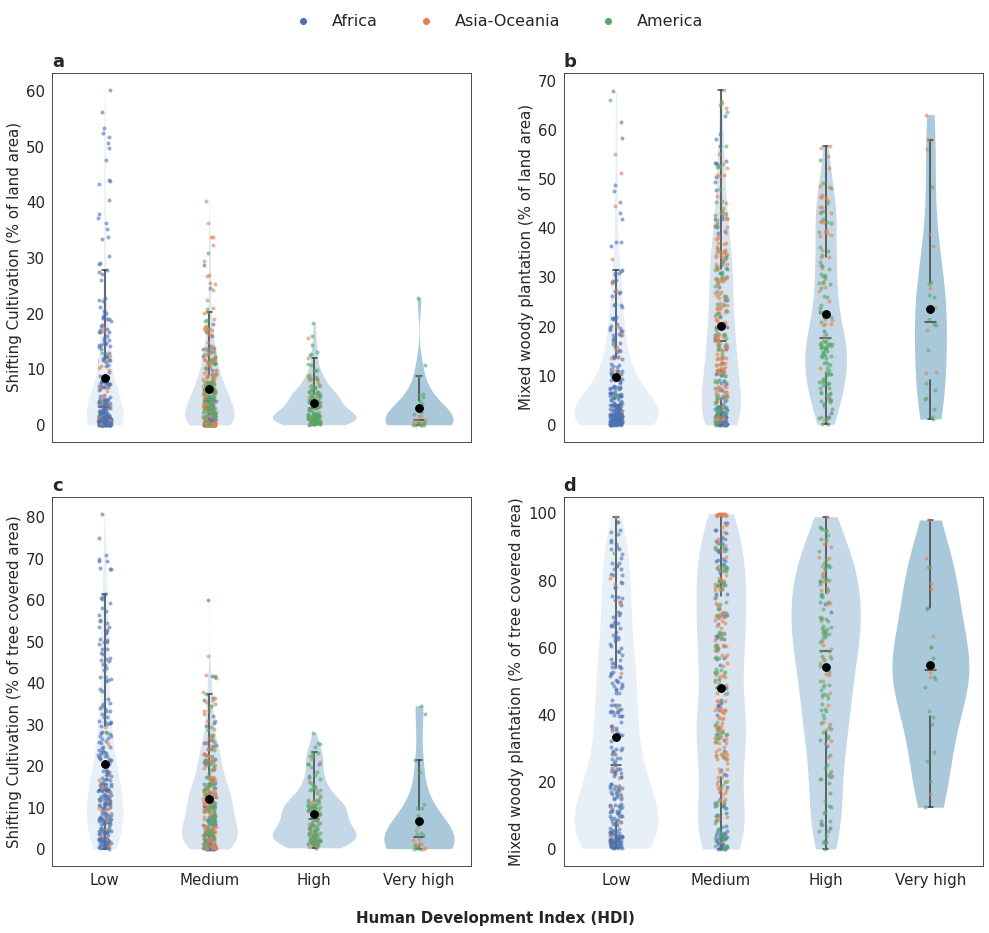

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# STYLE
# -----------------------------
sns.set_style("white")
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15
})

# -----------------------------
# Orders
# -----------------------------
hdi_order = ["Low", "Medium", "High", "Very high"]

continent_colors = {
    "Africa": "#4C72B0",
    "Asia-Oceania": "#DD8452",
    "America": "#55A868"
}

# -----------------------------
# Helper plot function
# -----------------------------
def draw_panel(ax, df, ycol, ylabel, title):

    # -------------------------
    # Violin — colored by HDI with transparency
    # -------------------------
    sns.violinplot(
        data=df,
        x="HDI_class",
        y=ycol,
        order=hdi_order,
        inner=None,
        cut=0,
        linewidth=0,
        palette=blue_palette,  # add 50% transparency via hex '80'
        ax=ax,
    )
 # -------------------------
    # Box — outline only
    # -------------------------
    sns.boxplot(
        data=df,
        x="HDI_class",
        y=ycol,
        order=hdi_order,
        width=0.1,
        showcaps=True,
        boxprops={'facecolor':'black', 'alpha':0.8},
        showfliers=False,
        whiskerprops={'linewidth':1.5},
        ax=ax
    )
    
    # -------------------------
    # Mean points
    # -------------------------
    means = df.groupby("HDI_class")[ycol].mean().reindex(hdi_order)
    for i, m in enumerate(means):
        ax.scatter(i, m,
                   color="black",
                   s=60,
                   zorder=10)

    # -------------------------
    # Scatter by continent
    # -------------------------
    for cont, color in continent_colors.items():
        sub = df[df["continent"] == cont]
        sns.stripplot(
        data=sub,
        x="HDI_class",
        y=ycol,
        order=hdi_order,
        color=color,
        size=4,
        alpha=0.6,
        jitter=0.06,
        ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=18)


# -----------------------------
# Figure layout
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,13), sharex=True)

draw_panel(
    axes[0,0],
    hdi_with_sc,
    "sc_in_land",
    "Shifting Cultivation (% of land area)",
    "a"
)

draw_panel(
    axes[0,1],
    hdi_with_sc,
    "m_in_land",
    "Mixed woody plantation (% of land area)",
    "b"
)

draw_panel(
    axes[1,0],
    hdi_with_sc,
    "sc_in_f_m",
    "Shifting Cultivation (% of tree covered area)",
    "c"
)

draw_panel(
    axes[1,1],
    hdi_with_sc,
    "m_in_f_s",
    "Mixed woody plantation (% of tree covered area)",
    "d"
)

# -----------------------------
# Legend for continents
# -----------------------------
handles = [
    plt.Line2D([], [], marker='o', linestyle='',
               color=c, label=k, markersize=6)
    for k, c in continent_colors.items()
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=16   
)

fig.supxlabel(
    "Human Development Index (HDI)",
    fontsize=15,
    fontweight="bold"
)


plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.subplots_adjust(wspace=0.22, hspace=0.15)

# plt.savefig(
#     "/mnt/warehouse/shifting_cultivation/111_result/figure/1paper/fig5.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()
